# Exercise: Probabilities of Bonding/Antibonding States in H2

## Learning goals
- Build a simple statistical model for H2 electronic configurations.
- Compute thermal probabilities with the Boltzmann distribution.
- Connect state probabilities to expected bond order.

## Physical model (simplified)

We use three coarse-grained electronic configurations:

1. **B**: both electrons in bonding orbital (lowest energy)
2. **M**: one electron in bonding and one in antibonding orbital
3. **A**: both electrons in antibonding orbital (highest energy)

We set their energies to:
- $E_B = 0$
- $E_M = \Delta$
- $E_A = 2\Delta$

and use degeneracies:
- $g_B = 1$
- $g_M = 4$
- $g_A = 1$

The degeneracies count how many microscopic spin configurations belong to each coarse-grained state.  
For **B** and **A**, both electrons occupy the same orbital, so only one spin-paired configuration is possible.  
For **M**, one electron is in the bonding orbital and one in the antibonding orbital, which gives four possible spin combinations, hence $g_M = 4$.

Bond-order contribution of each coarse-grained state:
- $BO_B = +1$
- $BO_M = 0$
- $BO_A = -1$


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Boltzmann constant in eV/K
k_B_eV = 8.617333262145e-5

# Model parameters
Delta_eV = 2.0
degeneracies = np.array([1.0, 4.0, 1.0])
energies_eV = np.array([0.0, Delta_eV, 2.0 * Delta_eV])
bond_orders = np.array([1.0, 0.0, -1.0])

state_labels = ["B (bonding,bonding)", "M (mixed)", "A (antibonding,antibonding)"]

## Task 1: Implement thermal probabilities


1. Write a function `state_probabilities(T, energies=energies_eV, g=degeneracies)` that computes the Boltzmann probability of each state at temperature $T$.
2. Use the partition function
   $$Z = \sum_i g_i e^{-E_i/(k_B T)}$$
3. With the Probability
   $$P_i = \frac{g_i e^{-E_i/(k_B T)}}{Z}$$

4.  Return a vector [P_B, P_M, P_A], where P_B, P_M, and P_A denote the probabilities of the bonding, mixed, and antibonding states.

In [21]:
def state_probabilities(T, energies=energies_eV, g=degeneracies):
    Z_sum = 0
    for i in range(len(energies)):
        Z_sum += g[i] * np.exp(-energies[i]/(k_B_eV*T))
    collector = []
    for i in range(len(energies)):
        P_i = (g[i] * np.exp(-energies[i]/(k_B_eV*T)))/Z_sum
        collector.append(P_i)
    return np.array(collector)

In [22]:
# Basic checks
p_300 = state_probabilities(300.0)
print(p_300)
assert np.isclose(np.sum(p_300), 1.0), "Probabilities must sum to 1."
assert np.all(p_300 >= 0.0), "Probabilities must be non-negative."

# Low-temperature limit: mostly bonding
p_low = state_probabilities(5.0)
assert p_low[0] > 0.999, "At very low T, bonding ground state should dominate."

# Very high-temperature limit: close to degeneracy ratio 1:4:1
p_high = state_probabilities(1e8)
p_inf_like = degeneracies / np.sum(degeneracies)
assert np.allclose(p_high, p_inf_like, atol=5e-3), "High-T limit should approach degeneracy fractions."

[1.00000000e+00 1.00818157e-33 6.35268804e-68]


## Task 2: Compute expected bond order

1. Use the probabilities from Task 1.
2. Compute the following expectation value `expected_bond_order` where $P_i$ is the return of the `state_probabilities()` function and $BO_i$ is the `bond_order` array defined in the first cell.
   $$\langle BO \rangle = \sum_i P_i \, BO_i$$


In [23]:
def expected_bond_order(temperature, bonds=bond_orders):
    sum = 0
    probs = state_probabilities(temperature)
    for i in range(len(probs)):
        sum += probs[i] * bonds[i]
    return sum

In [24]:
bo_low = expected_bond_order(5.0)
bo_room = expected_bond_order(300.0)
bo_high = expected_bond_order(1e8)

assert bo_low > 0.999, "At very low T, bond order should be near +1."
assert bo_high < 1e-2 and bo_high > -1e-2, "At very high T, expected bond order should approach 0 in this model."
assert bo_low >= bo_room >= bo_high - 1e-9, "Bond order should decrease with increasing T in this setup."

print(f"<BO>(5 K)   = {bo_low:.6f}")
print(f"<BO>(300 K) = {bo_room:.6f}")
print(f"<BO>(1e8 K) = {bo_high:.6f}")

<BO>(5 K)   = 1.000000
<BO>(300 K) = 1.000000
<BO>(1e8 K) = 0.000077


## Task 3: Sweep temperature and visualize

In this task, compute how the thermal population of the three coarse-grained states changes with temperature.

1. Generate a logarithmic temperature grid with `np.logspace()`starting from 0 to 8 with 300 steps and base = 10. 
2. For each temperature, compute the state probabilities
   $$
   [P_B, P_M, P_A]
   $$
   using `state_probabilities(T)`.
3. Explicitly extract the three arrays `P_B`, `P_M`, and `P_A` from the result, since they should be used for plotting.
4. Compute the expected bond order $\langle BO \rangle$ over the same temperature grid.
5. Plot the thermal populations as functions of temperature.  
   The three probabilities should be shown clearly (either in one combined plot or in separate curves with labels), and the expected bond order should also be plotted.
6. Use the numerical checks below as sanity tests:
   - $P_B$ should not increase with temperature,
   - $P_A$ should not decrease with temperature,
   - the expected bond order should not increase with temperature.

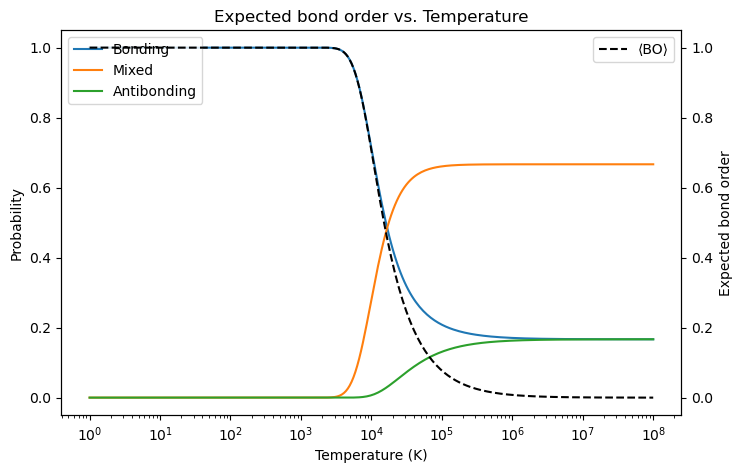

In [25]:
temp_grid = np.logspace(0, 8, 300, True, 10.0)
P_B_list, P_M_list, P_A_list = [], [], []
bo_list = []

for temp in temp_grid:
    probs = state_probabilities(temp)
    P_B_list.append(probs[0])
    P_M_list.append(probs[1])
    P_A_list.append(probs[2])
    bo_list.append(expected_bond_order(temp))

P_B = np.array(P_B_list)
P_M = np.array(P_M_list)
P_A = np.array(P_A_list)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.semilogx(temp_grid, P_B, label="Bonding")
ax1.semilogx(temp_grid, P_M, label="Mixed")
ax1.semilogx(temp_grid, P_A, label="Antibonding")
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Probability")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.semilogx(temp_grid, np.array(bo_list), color="black", linestyle="--", label="⟨BO⟩")
ax2.set_ylabel("Expected bond order")
ax2.legend(loc="upper right")

plt.title("Expected bond order vs. Temperature")
plt.show()

In [26]:
assert np.all(np.diff(P_B) <= 1e-10), "P_B should not increase with T."
assert np.all(np.diff(P_A) >= -1e-10), "P_A should not decrease with T."